# Supervised ML Pipeline: Predicting Student At-Risk Status

This notebook trains and evaluates a classifier to predict `at_risk` (binary classification) using engineered features.

**Target:** `at_risk` (1 = Fail/Withdrawn, 0 = Pass/Distinction)

**Reporting only:** `final_result` (not used as feature)


## 0. Setup


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import seaborn, install if missing
try:
    import seaborn as sns
except ImportError:
    print("seaborn not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--quiet"])
    import seaborn as sns
    print("seaborn installed successfully.")

from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Try to import scikit-learn, install if missing
try:
    from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import (
        precision_score, recall_score, f1_score, roc_auc_score,
        confusion_matrix, roc_curve, classification_report
    )
except ImportError:
    print("scikit-learn not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "--quiet"])
    from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import (
        precision_score, recall_score, f1_score, roc_auc_score,
        confusion_matrix, roc_curve, classification_report
    )
    print("scikit-learn installed successfully.")

# Try to import scipy, install if missing
try:
    from scipy.stats import randint, uniform
except ImportError:
    print("scipy not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "--quiet"])
    from scipy.stats import randint, uniform
    print("scipy installed successfully.")

# Create directories
os.makedirs('./reports', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")


scikit-learn not found. Attempting to install...
scikit-learn installed successfully.
Setup complete.


## 1. Problem framing

### Business Objective
Predict which students are at risk of failing or withdrawing from their course.

### ML Task
- **Type:** Binary classification
- **Target:** `at_risk` (1 = at risk, 0 = not at risk)
- **Evaluation:** F1 score (balanced metric for imbalanced classes)

### Success Criteria
- F1 score > baseline (most frequent class)
- Model interpretability for actionable insights
- No data leakage (students not split across train/test)


## 2. Data loading (features file)


In [4]:
# Try parquet first, fallback to CSV
if os.path.exists('./data/features_supervised.parquet'):
    df = pd.read_parquet('./data/features_supervised.parquet')
    print(f"Loaded from parquet: {df.shape}")
elif os.path.exists('./data/features_supervised.csv'):
    df = pd.read_csv('./data/features_supervised.csv')
    print(f"Loaded from CSV: {df.shape}")
else:
    raise FileNotFoundError("Neither ./data/features_supervised.parquet nor ./data/features_supervised.csv found")

print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
print(f"\nShape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Loaded from CSV: (32593, 46)

Columns (46): ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'mean_score', 'max_score', 'score_count', 'submissions_count', 'assessments_count', 'total_assessments_available', 'missed_submissions_count', 'avg_submission_delay', 'total_clicks', 'active_days', 'clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url', 'clicks_early', 'clicks_mid', 'clicks_late', 'at_risk']

Shape: (32593, 46)

Memory usage: 27.01 MB


## 3. Data understanding (EDA + quality checks)


In [5]:
# Basic info
print("=== BASIC INFO ===")
print(f"Shape: {df.shape}")
print(f"\nUnique students: {df['id_student'].nunique()}")
print(f"Unique (student, module, presentation): {df.groupby(['id_student', 'code_module', 'code_presentation']).size().shape[0]}")

# Check for duplicates
duplicates = df.duplicated(subset=['id_student', 'code_module', 'code_presentation']).sum()
print(f"\nDuplicate keys: {duplicates}")
assert duplicates == 0, "Duplicate keys found!"


=== BASIC INFO ===
Shape: (32593, 46)

Unique students: 28785
Unique (student, module, presentation): 32593

Duplicate keys: 0


In [6]:
# Target variable distribution
print("=== TARGET VARIABLE ===")
print(f"\nat_risk distribution:")
print(df['at_risk'].value_counts())
print(f"\nat_risk proportion:")
print(df['at_risk'].value_counts(normalize=True))

if 'final_result' in df.columns:
    print(f"\nfinal_result distribution:")
    print(df['final_result'].value_counts())
    print(f"\nCross-tabulation:")
    print(pd.crosstab(df['final_result'], df['at_risk'], margins=True))


=== TARGET VARIABLE ===

at_risk distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64

at_risk proportion:
at_risk
1    0.527966
0    0.472034
Name: proportion, dtype: float64

final_result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Cross-tabulation:
at_risk           0      1    All
final_result                     
Distinction    3024      0   3024
Fail              0   7052   7052
Pass          12361      0  12361
Withdrawn         0  10156  10156
All           15385  17208  32593


In [7]:
# Missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)

if len(missing_df) == 0:
    print("\nNo missing values found.")


=== MISSING VALUES ===
                             missing_count  missing_pct
mean_score                            6773        20.78
max_score                             6773        20.78
avg_submission_delay                  6751        20.71
score_count                           6750        20.71
submissions_count                     6750        20.71
assessments_count                     6750        20.71
total_assessments_available           6750        20.71
missed_submissions_count              6750        20.71
clicks_resource                       3365        10.32
clicks_page                           3365        10.32
clicks_questionnaire                  3365        10.32
clicks_quiz                           3365        10.32
clicks_repeatactivity                 3365        10.32
clicks_url                            3365        10.32
clicks_sharedsubpage                  3365        10.32
clicks_subpage                        3365        10.32
clicks_ouelluminate      

In [8]:
# Data types
print("=== DATA TYPES ===")
print(df.dtypes.value_counts())

# Numeric columns summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id_student', 'at_risk']]
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:10]}..." if len(numeric_cols) > 10 else f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ['id_student', 'code_module', 'code_presentation', 'final_result']]
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols[:10]}..." if len(categorical_cols) > 10 else f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


=== DATA TYPES ===
float64    33
object      9
int64       4
Name: count, dtype: int64

Numeric columns (35): ['num_of_prev_attempts', 'studied_credits', 'mean_score', 'max_score', 'score_count', 'submissions_count', 'assessments_count', 'total_assessments_available', 'missed_submissions_count', 'avg_submission_delay']...

Categorical columns (6): ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


In [9]:
# Check for leakage: features that directly encode final outcome
print("=== LEAKAGE CHECK ===")
leakage_keywords = ['final', 'result', 'outcome', 'grade', 'overall', 'exam_score', 'total_score']
potential_leakage = []

for col in df.columns:
    if col.lower() in ['final_result', 'at_risk']:
        continue
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in leakage_keywords):
        potential_leakage.append(col)

if potential_leakage:
    print(f"\n⚠️  Potential leakage features detected: {potential_leakage}")
    print("\nThese will be excluded from features.")
else:
    print("\n✓ No obvious leakage features detected.")


=== LEAKAGE CHECK ===

✓ No obvious leakage features detected.


## 4. Data preparation (preprocessing for ML)


In [10]:
# Separate target and features
y = df['at_risk'].copy()

# Exclude target, final_result, and key columns from features
exclude_cols = ['at_risk', 'final_result', 'id_student', 'code_module', 'code_presentation']

# Also exclude potential leakage features
if 'potential_leakage' in locals():
    exclude_cols.extend(potential_leakage)

X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

print(f"Target shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"\nExcluded columns: {exclude_cols}")
print(f"\nFeature columns ({len(X.columns)}): {list(X.columns)}")


Target shape: (32593,)
Features shape: (32593, 41)

Excluded columns: ['at_risk', 'final_result', 'id_student', 'code_module', 'code_presentation']

Feature columns (41): ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'mean_score', 'max_score', 'score_count', 'submissions_count', 'assessments_count', 'total_assessments_available', 'missed_submissions_count', 'avg_submission_delay', 'total_clicks', 'active_days', 'clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url', 'clicks_early', 'clicks_mid', 'clicks_late']


In [11]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Store feature names for later use
all_feature_names = numeric_features + categorical_features


Numeric features: 35
Categorical features: 6


In [12]:
# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline created.")
print(f"Numeric transformer: median imputation + StandardScaler")
print(f"Categorical transformer: 'Unknown' imputation + OneHotEncoder (drop='first')")


Preprocessing pipeline created.
Numeric transformer: median imputation + StandardScaler
Categorical transformer: 'Unknown' imputation + OneHotEncoder (drop='first')


## 5. Train/validation/test split (leakage-safe)


In [13]:
# Use GroupShuffleSplit to prevent same student in train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Group by id_student
groups = df['id_student'].values

# Split
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain set unique students: {len(np.unique(groups_train))}")
print(f"Test set unique students: {len(np.unique(groups_test))}")


Train set: 26122 samples
Test set: 6471 samples

Train set unique students: 23028
Test set unique students: 5757


In [14]:
# Verify no overlap of students between train and test
train_students = set(groups_train)
test_students = set(groups_test)
overlap = train_students.intersection(test_students)

print(f"Train students: {len(train_students)}")
print(f"Test students: {len(test_students)}")
print(f"Overlapping students: {len(overlap)}")

if len(overlap) > 0:
    print(f"\n⚠️  WARNING: Found {len(overlap)} overlapping students!")
    print(f"Sample overlapping IDs: {list(overlap)[:5]}")
else:
    print("\n✓ No student overlap between train and test sets.")


Train students: 23028
Test students: 5757
Overlapping students: 0

✓ No student overlap between train and test sets.


In [15]:
# Check class distribution in splits
print("=== CLASS DISTRIBUTION ===")
print(f"\nTrain set:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set:")
print(y_test.value_counts(normalize=True))

# Note: Stratification with GroupShuffleSplit is limited
# We verify approximate balance instead
train_at_risk_pct = y_train.mean() * 100
test_at_risk_pct = y_test.mean() * 100
print(f"\nTrain at_risk %: {train_at_risk_pct:.2f}%")
print(f"Test at_risk %: {test_at_risk_pct:.2f}%")
print(f"Difference: {abs(train_at_risk_pct - test_at_risk_pct):.2f}%")

if abs(train_at_risk_pct - test_at_risk_pct) > 5:
    print("\n⚠️  Note: Class distribution differs >5% between train/test.")


=== CLASS DISTRIBUTION ===

Train set:
at_risk
1    0.528673
0    0.471327
Name: proportion, dtype: float64

Test set:
at_risk
1    0.525112
0    0.474888
Name: proportion, dtype: float64

Train at_risk %: 52.87%
Test at_risk %: 52.51%
Difference: 0.36%


## 6. Baseline model


In [16]:
# Baseline 1: DummyClassifier (most frequent)
print("=== BASELINE 1: DummyClassifier (most_frequent) ===")

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_precision = precision_score(y_test, y_pred_dummy)
dummy_recall = recall_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_pred_proba_dummy)

print(f"Precision: {dummy_precision:.4f}")
print(f"Recall: {dummy_recall:.4f}")
print(f"F1: {dummy_f1:.4f}")
print(f"ROC-AUC: {dummy_roc_auc:.4f}")


=== BASELINE 1: DummyClassifier (most_frequent) ===
Precision: 0.5251
Recall: 1.0000
F1: 0.6886
ROC-AUC: 0.5000


In [17]:
# Baseline 2: LogisticRegression
print("=== BASELINE 2: LogisticRegression ===")

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1: {lr_f1:.4f}")
print(f"ROC-AUC: {lr_roc_auc:.4f}")


=== BASELINE 2: LogisticRegression ===
Precision: 0.9022
Recall: 0.8961
F1: 0.8992
ROC-AUC: 0.9526


## 7. Main model


In [18]:
# Main model: RandomForestClassifier with RandomizedSearchCV
print("=== MAIN MODEL: RandomForestClassifier ===")

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

# Hyperparameter search space (small, fast search)
param_distributions = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 5)
}

# Use GroupShuffleSplit for cross-validation to prevent leakage
cv = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions,
    n_iter=20,  # Small search space
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter search...")
random_search.fit(X_train, y_train, groups=groups_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV F1 score: {random_search.best_score_:.4f}")


=== MAIN MODEL: RandomForestClassifier ===
Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 181}
Best CV F1 score: 0.9368


In [19]:
# Evaluate best model on test set
best_model = random_search.best_estimator_

y_pred_rf = best_model.predict(X_test)
y_pred_proba_rf = best_model.predict_proba(X_test)[:, 1]

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"=== TEST SET RESULTS ===")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")


=== TEST SET RESULTS ===
Precision: 0.9704
Recall: 0.8973
F1: 0.9324
ROC-AUC: 0.9798


## 8. Evaluation


In [20]:
# Create metrics comparison table
metrics_df = pd.DataFrame({
    'Model': ['Dummy (most_frequent)', 'LogisticRegression', 'RandomForest (tuned)'],
    'Precision': [dummy_precision, lr_precision, rf_precision],
    'Recall': [dummy_recall, lr_recall, rf_recall],
    'F1': [dummy_f1, lr_f1, rf_f1],
    'ROC-AUC': [dummy_roc_auc, lr_roc_auc, rf_roc_auc]
})

print("=== METRICS COMPARISON ===")
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv('./reports/metrics.csv', index=False)
print("\nSaved: ./reports/metrics.csv")


=== METRICS COMPARISON ===
                Model  Precision   Recall       F1  ROC-AUC
Dummy (most_frequent)   0.525112 1.000000 0.688621 0.500000
   LogisticRegression   0.902222 0.896115 0.899158 0.952624
 RandomForest (tuned)   0.970401 0.897293 0.932416 0.979785

Saved: ./reports/metrics.csv


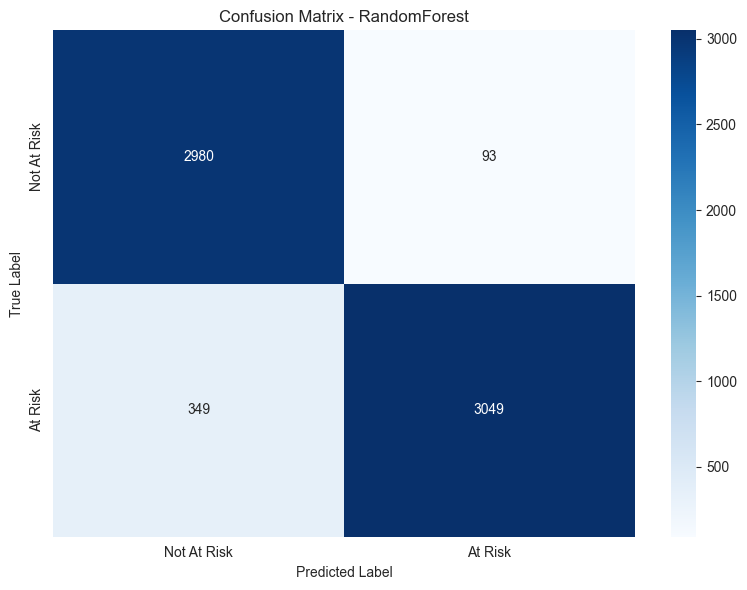

Saved: ./reports/confusion_matrix.png


In [21]:
# Confusion matrix for RandomForest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not At Risk', 'At Risk'],
            yticklabels=['Not At Risk', 'At Risk'])
plt.title('Confusion Matrix - RandomForest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('./reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/confusion_matrix.png")


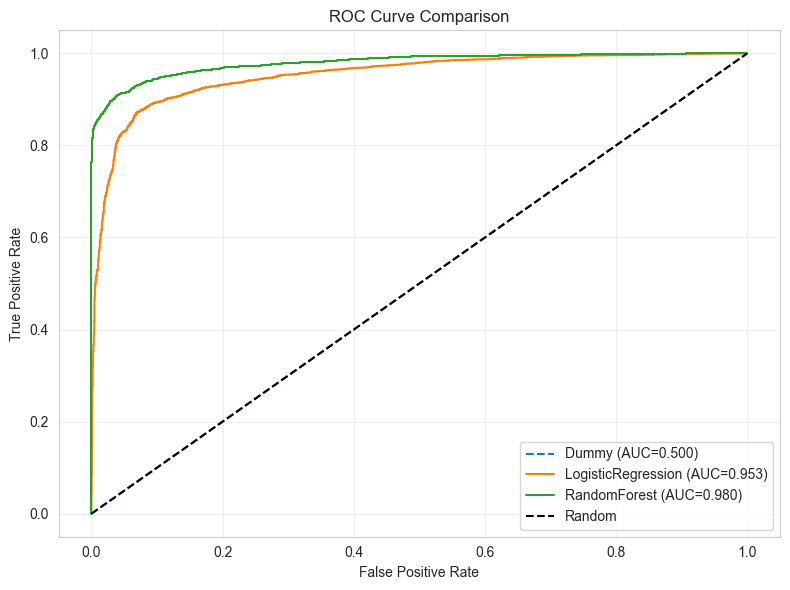

Saved: ./reports/roc_curve.png


In [22]:
# ROC curve comparison
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dummy, tpr_dummy, label=f'Dummy (AUC={dummy_roc_auc:.3f})', linestyle='--')
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC={lr_roc_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={rf_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/roc_curve.png")


## 9. Interpretability


In [23]:
# LogisticRegression coefficients
print("=== LOGISTIC REGRESSION: TOP COEFFICIENTS ===")

# Get feature names from OneHotEncoder
lr_preprocessor = lr_pipeline.named_steps['preprocessor']
lr_classifier = lr_pipeline.named_steps['classifier']

# Get feature names
feature_names = []

# Numeric features
feature_names.extend(numeric_features)

# Categorical features (from OneHotEncoder)
cat_transformer = lr_preprocessor.named_transformers_['cat']
onehot = cat_transformer.named_steps['onehot']
cat_feature_names = onehot.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get coefficients
coefficients = lr_classifier.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Sort by absolute value
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\nTop 10 positive coefficients (increase at_risk probability):")
print(coef_df[coef_df['coefficient'] > 0].head(10)[['feature', 'coefficient']].to_string(index=False))

print("\nTop 10 negative coefficients (decrease at_risk probability):")
print(coef_df[coef_df['coefficient'] < 0].head(10)[['feature', 'coefficient']].to_string(index=False))


=== LOGISTIC REGRESSION: TOP COEFFICIENTS ===

Top 10 positive coefficients (increase at_risk probability):
                             feature  coefficient
                        total_clicks    11.521395
                        clicks_early     5.985760
                         clicks_late     4.125737
                          clicks_mid     2.330928
                         clicks_page     0.564320
highest_education_Lower Than A Level     0.532946
   highest_education_No Formal quals     0.464909
                            gender_M     0.367848
                region_London Region     0.248186
                     studied_credits     0.232717

Top 10 negative coefficients (decrease at_risk probability):
         feature  coefficient
clicks_oucontent    -9.227069
  clicks_forumng    -7.802773
     clicks_quiz    -6.101940
 clicks_homepage    -4.548637
     active_days    -2.023320
   clicks_ouwiki    -1.845454
  clicks_subpage    -1.427198
 clicks_resource    -1.319752
     score

In [24]:
# RandomForest feature importances
print("=== RANDOM FOREST: FEATURE IMPORTANCES ===")

# Get feature names (same as LogisticRegression)
rf_preprocessor = best_model.named_steps['preprocessor']
rf_classifier = best_model.named_steps['classifier']

# Get feature names
rf_feature_names = []
rf_feature_names.extend(numeric_features)

rf_cat_transformer = rf_preprocessor.named_transformers_['cat']
rf_onehot = rf_cat_transformer.named_steps['onehot']
rf_cat_feature_names = rf_onehot.get_feature_names_out(categorical_features)
rf_feature_names.extend(rf_cat_feature_names)

# Get importances
importances = rf_classifier.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
print(importance_df.head(20).to_string(index=False))


=== RANDOM FOREST: FEATURE IMPORTANCES ===

Top 20 most important features:
                    feature  importance
                 clicks_mid    0.213779
                clicks_late    0.103540
                active_days    0.079799
total_assessments_available    0.061823
                 mean_score    0.058558
          submissions_count    0.058326
                score_count    0.056299
          assessments_count    0.053403
            clicks_homepage    0.051416
               total_clicks    0.037031
                  max_score    0.032991
           clicks_oucontent    0.020879
            clicks_resource    0.020131
       avg_submission_delay    0.019238
             clicks_forumng    0.017100
                clicks_quiz    0.015005
               clicks_early    0.014980
             clicks_subpage    0.014808
                 clicks_url    0.013044
              clicks_ouwiki    0.012264


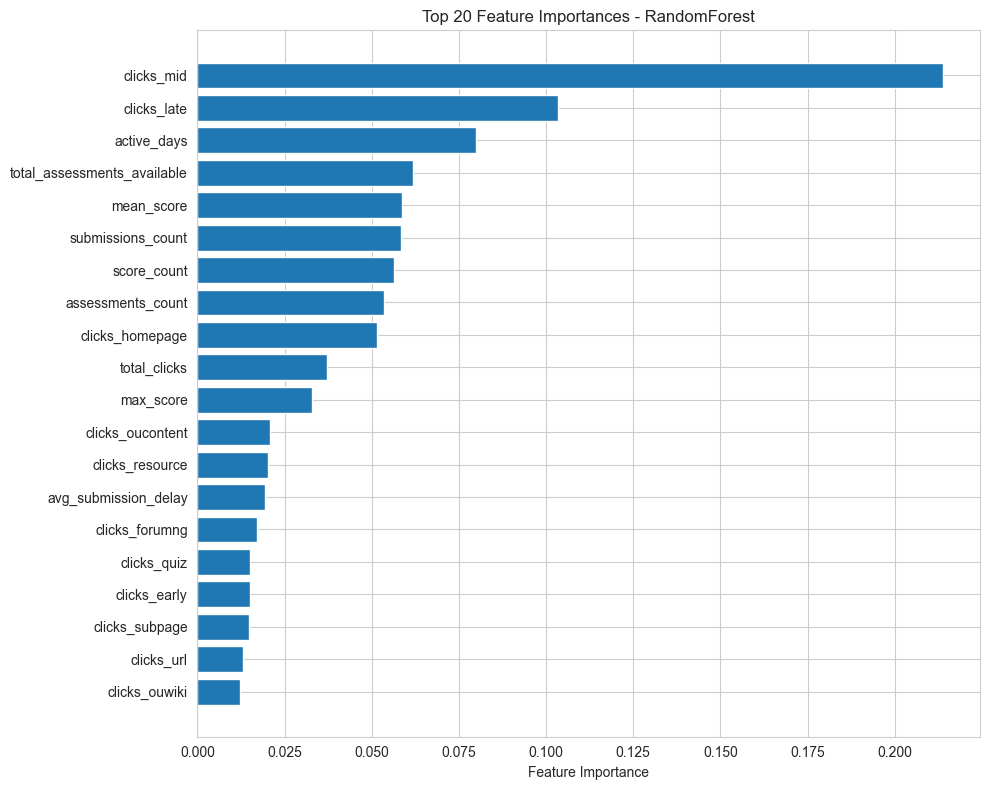

Saved: ./reports/feature_importance.png


In [25]:
# Plot feature importances
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances - RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('./reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/feature_importance.png")


## 10. Error analysis


In [26]:
# Create error analysis DataFrame
error_df = X_test.copy()
error_df['id_student'] = df.iloc[test_idx]['id_student'].values
error_df['final_result'] = df.iloc[test_idx]['final_result'].values
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_pred_rf
error_df['y_pred_proba'] = y_pred_proba_rf

# Identify errors
error_df['error_type'] = 'Correct'
error_df.loc[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1), 'error_type'] = 'False Positive'

print(f"=== ERROR SUMMARY ===")
print(error_df['error_type'].value_counts())
print(f"\nFalse Negative Rate: {(error_df['error_type'] == 'False Negative').sum() / (y_test == 1).sum() * 100:.2f}%")
print(f"False Positive Rate: {(error_df['error_type'] == 'False Positive').sum() / (y_test == 0).sum() * 100:.2f}%")


=== ERROR SUMMARY ===
error_type
Correct           6029
False Negative     349
False Positive      93
Name: count, dtype: int64

False Negative Rate: 10.27%
False Positive Rate: 3.03%


In [27]:
# Top 20 False Negatives (predicted not at risk, but actually at risk)
print("=== TOP 20 FALSE NEGATIVES ===")
fn = error_df[error_df['error_type'] == 'False Negative'].copy()
fn = fn.sort_values('y_pred_proba', ascending=True)  # Lowest predicted probability

# Select key columns for display
display_cols = ['id_student', 'final_result', 'y_pred_proba']
# Add a few feature columns if they exist
if 'mean_score' in fn.columns:
    display_cols.append('mean_score')
if 'total_clicks' in fn.columns:
    display_cols.append('total_clicks')

print(fn[display_cols].head(20).to_string(index=False))


=== TOP 20 FALSE NEGATIVES ===
 id_student final_result  y_pred_proba  mean_score  total_clicks
     548190         Fail      0.002338   81.666667         883.0
     445109         Fail      0.008904   76.428571        1396.0
     596596         Fail      0.011194   83.545455         800.0
     532868         Fail      0.012989   83.000000        2775.0
     368886         Fail      0.015281   87.083333        4795.0
     542707         Fail      0.018789   81.636364         666.0
     510149         Fail      0.019463   83.545455        3041.0
     637388         Fail      0.021609   60.200000        2300.0
     596002    Withdrawn      0.024240   86.250000        1425.0
     628119         Fail      0.025894   84.300000        1179.0
     564617         Fail      0.027356   72.083333        6139.0
     647200         Fail      0.029785   71.800000        1153.0
     199361         Fail      0.034560   82.666667        1580.0
     573294         Fail      0.035011   85.000000         

In [28]:
# Top 20 False Positives (predicted at risk, but actually not at risk)
print("=== TOP 20 FALSE POSITIVES ===")
fp = error_df[error_df['error_type'] == 'False Positive'].copy()
fp = fp.sort_values('y_pred_proba', ascending=False)  # Highest predicted probability

print(fp[display_cols].head(20).to_string(index=False))


=== TOP 20 FALSE POSITIVES ===
 id_student final_result  y_pred_proba  mean_score  total_clicks
     696485         Pass      0.942829   76.000000         542.0
     599016         Pass      0.894903   60.000000         106.0
     226895         Pass      0.872443   73.000000           6.0
    2004220         Pass      0.863639   62.333333         505.0
     358075         Pass      0.847588   73.833333         214.0
     573550         Pass      0.844469   67.666667        1102.0
     573377         Pass      0.823098   51.625000        1047.0
     566428         Pass      0.804843   72.666667         289.0
     654002  Distinction      0.792173   93.000000         912.0
     647502         Pass      0.771594   51.000000         275.0
     695049         Pass      0.766678   70.200000           9.0
    2025589         Pass      0.757558   78.000000         125.0
     652553         Pass      0.753399   40.600000          60.0
     572447         Pass      0.743128   84.857143         

In [29]:
# Slice analysis by demographic (if available)
print("=== SLICE ANALYSIS BY DEMOGRAPHIC ===")

demographic_cols = ['gender', 'disability']
available_demographics = [col for col in demographic_cols if col in error_df.columns]

if available_demographics:
    for demo_col in available_demographics:
        print(f"\n--- By {demo_col} ---")
        slice_metrics = error_df.groupby(demo_col).agg({
            'y_true': 'sum',  # Actual at_risk count
            'y_pred': 'sum',  # Predicted at_risk count
            'error_type': lambda x: (x == 'False Negative').sum(),  # FN count
            'y_pred_proba': 'mean'  # Avg predicted probability
        }).round(4)
        slice_metrics.columns = ['Actual_AtRisk', 'Predicted_AtRisk', 'False_Negatives', 'Avg_Proba']
        
        # Calculate precision and recall per slice
        for val in error_df[demo_col].unique():
            slice_data = error_df[error_df[demo_col] == val]
            if len(slice_data) > 0:
                slice_precision = precision_score(slice_data['y_true'], slice_data['y_pred'])
                slice_recall = recall_score(slice_data['y_true'], slice_data['y_pred'])
                slice_f1 = f1_score(slice_data['y_true'], slice_data['y_pred'])
                slice_metrics.loc[val, 'Precision'] = slice_precision
                slice_metrics.loc[val, 'Recall'] = slice_recall
                slice_metrics.loc[val, 'F1'] = slice_f1
        
        print(slice_metrics)
        
        # Note limitations
        print(f"\n⚠️  Note: Slice analysis limited by sample size and potential confounding factors.")
else:
    print("No demographic columns available for slice analysis.")


=== SLICE ANALYSIS BY DEMOGRAPHIC ===

--- By gender ---
        Actual_AtRisk  Predicted_AtRisk  False_Negatives  Avg_Proba  \
gender                                                                
F                1482              1348              175     0.5085   
M                1916              1794              174     0.5315   

        Precision    Recall        F1  
gender                                 
F        0.969585  0.881916  0.923675  
M        0.971014  0.909186  0.939084  

⚠️  Note: Slice analysis limited by sample size and potential confounding factors.

--- By disability ---
            Actual_AtRisk  Predicted_AtRisk  False_Negatives  Avg_Proba  \
disability                                                                
N                    3010              2779              311     0.5128   
Y                     388               363               38     0.5986   

            Precision    Recall        F1  
disability                                 
N 

## 11. Save outputs


In [31]:
# Create results summary markdown
summary = f"""# Model Results Summary

## Model Performance

| Model | Precision | Recall | F1 | ROC-AUC |
|-------|-----------|--------|----|---------|
| Dummy (most_frequent) | {dummy_precision:.4f} | {dummy_recall:.4f} | {dummy_f1:.4f} | {dummy_roc_auc:.4f} |
| LogisticRegression | {lr_precision:.4f} | {lr_recall:.4f} | {lr_f1:.4f} | {lr_roc_auc:.4f} |
| RandomForest (tuned) | {rf_precision:.4f} | {rf_recall:.4f} | {rf_f1:.4f} | {rf_roc_auc:.4f} |

## Key Findings

- **Best Model:** RandomForestClassifier with hyperparameter tuning
- **Best F1 Score:** {rf_f1:.4f}
- **Best ROC-AUC:** {rf_roc_auc:.4f}
- **Improvement over baseline:** F1 improved by {rf_f1 - dummy_f1:.4f} ({((rf_f1 - dummy_f1) / dummy_f1 * 100):.1f}%)

## Data Summary

- **Total samples:** {len(df)}
- **Train samples:** {len(X_train)}
- **Test samples:** {len(X_test)}
- **Unique students (train):** {len(np.unique(groups_train))}
- **Unique students (test):** {len(np.unique(groups_test))}
- **No student overlap:** ✓ Verified

## Top Features (RandomForest)

1. {importance_df.iloc[0]['feature']} (importance: {importance_df.iloc[0]['importance']:.4f})
2. {importance_df.iloc[1]['feature']} (importance: {importance_df.iloc[1]['importance']:.4f})
3. {importance_df.iloc[2]['feature']} (importance: {importance_df.iloc[2]['importance']:.4f})

## Error Analysis

- **False Negatives:** {(error_df['error_type'] == 'False Negative').sum()} (missed at-risk students)
- **False Positives:** {(error_df['error_type'] == 'False Positive').sum()} (incorrectly flagged as at-risk)

## Files Generated

- `metrics.csv` - Detailed metrics comparison
- `confusion_matrix.png` - Confusion matrix visualization
- `roc_curve.png` - ROC curve comparison
- `feature_importance.png` - Top feature importances
- `results_summary.md` - This summary

"""

with open('./reports/results_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print("Saved: ./reports/results_summary.md")
print("\n=== ALL OUTPUTS SAVED ===")
print("\nGenerated files:")
print("- ./reports/metrics.csv")
print("- ./reports/confusion_matrix.png")
print("- ./reports/roc_curve.png")
print("- ./reports/feature_importance.png")
print("- ./reports/results_summary.md")


Saved: ./reports/results_summary.md

=== ALL OUTPUTS SAVED ===

Generated files:
- ./reports/metrics.csv
- ./reports/confusion_matrix.png
- ./reports/roc_curve.png
- ./reports/feature_importance.png
- ./reports/results_summary.md
